In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "duckdb",
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "pyarrow",
#     "seaborn",
# ]
#
# [tool.uv]
# exclude-newer = "2025-08-18T11:52:55.787465233+02:00"
# ///

In [ ]:
import duckdb
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LogNorm
import seaborn as sns

In [3]:
conn = duckdb.connect(database=':memory:')

conn.execute("""
CREATE OR REPLACE VIEW flows AS
FROM read_parquet(
             '../data/flows/v1.1/year=*/month=*/day=*/flows.parquet',
             hive_partitioning=True);
""");

In [4]:
label_distribution = conn.sql("""
SELECT
    MAKE_DATE(
        CAST(year AS BIGINT),
        CAST(month AS BIGINT),
        CAST(day AS BIGINT)) AS date,
    Label as label,
    COUNT(label) as count
FROM flows
GROUP BY date, label
ORDER BY date
""").pl().pivot('label', index='date', values='count').fill_nan(0)

In [5]:
taxonomy_distribution = conn.sql("""
SELECT
    MAKE_DATE(
        CAST(year AS BIGINT),
        CAST(month AS BIGINT),
        CAST(day AS BIGINT)) AS date,
    taxonomy,
    COUNT(taxonomy) as count
FROM flows
GROUP BY date, taxonomy
ORDER BY date
""").pl().pivot('taxonomy', index='date', values='count').fill_nan(0)

In [6]:
heuristic_distribution = conn.sql("""
SELECT
    MAKE_DATE(
        CAST(year AS BIGINT),
        CAST(month AS BIGINT),
        CAST(day AS BIGINT)) AS date,
    heuristic,
    COUNT(heuristic) as count
FROM flows
GROUP BY date, heuristic
ORDER BY date
""").pl().pivot('heuristic', index='date', values='count').fill_nan(0)

## Label distribution

In [7]:
label_colors = {
    "anomalous": "#d62728",  # red (danger)
    "benign":    "#2ca02c",  # green (safe)
    "notice":    "#1f77b4",  # blue (informational)
    "suspicious": "#ff7f0e", # orange (warning)
}

def get_label_colors(columns):
    return [label_colors.get(col, "#333333") for col in columns]

In [8]:
labels = label_distribution.columns
labels.remove('date')

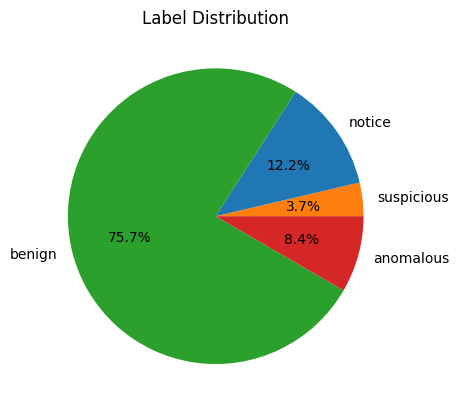

In [9]:
label_distribution.select(labels).sum().\
    to_pandas().iloc[0].plot.pie(
        autopct='%1.1f%%',
        colors=get_label_colors(labels)
    ).set_title("Label Distribution")
plt.ylabel("")
plt.show()

In [10]:
label_distribution_1mo = (
    label_distribution
    .group_by(month=pl.col("date").dt.truncate("1mo"))
    .agg(pl.exclude("date").sum())
    .sort("month")
).to_pandas().set_index('month', drop=True)

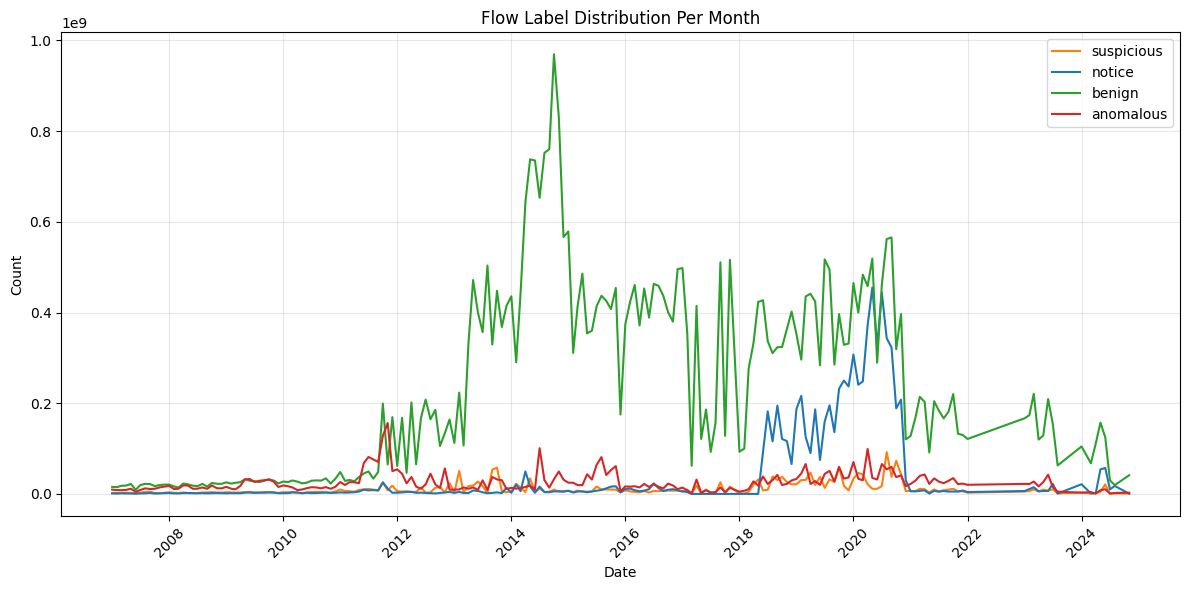

In [11]:
plt.figure(figsize=(12, 6))
for column in label_distribution_1mo.columns:
    sns.lineplot(
        x=label_distribution_1mo.index,
        y=label_distribution_1mo[column],
        label=column,
        color=label_colors.get(column)
    )

plt.title("Flow Label Distribution Per Month")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
label_distribution_1mo_rel = label_distribution_1mo.div(
    label_distribution_1mo.sum(axis=1), axis=0) * 100

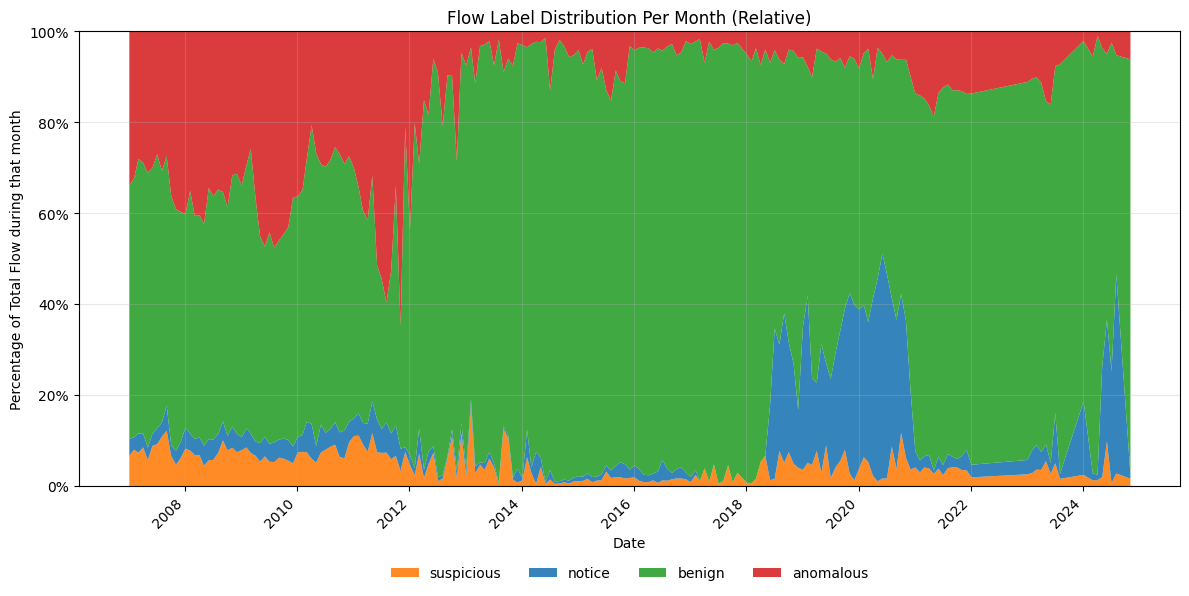

In [40]:
plt.figure(figsize=(12, 6))
cols = list(label_distribution_1mo_rel.columns)
colors = [label_colors.get(c, "#333333") for c in cols]
# Ensure no NaN
area_df = label_distribution_1mo_rel[cols].fillna(0)
area_df.plot.area(
    stacked=True,
    color=colors,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.9
)
plt.title("Flow Label Distribution Per Month (Relative)")
plt.xlabel("Date")
plt.ylabel("Percentage of Total Flow during that month")
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(loc='upper center', ncol=len(cols), bbox_to_anchor=(0.5, -0.15), frameon=False)
plt.tight_layout()
plt.show()

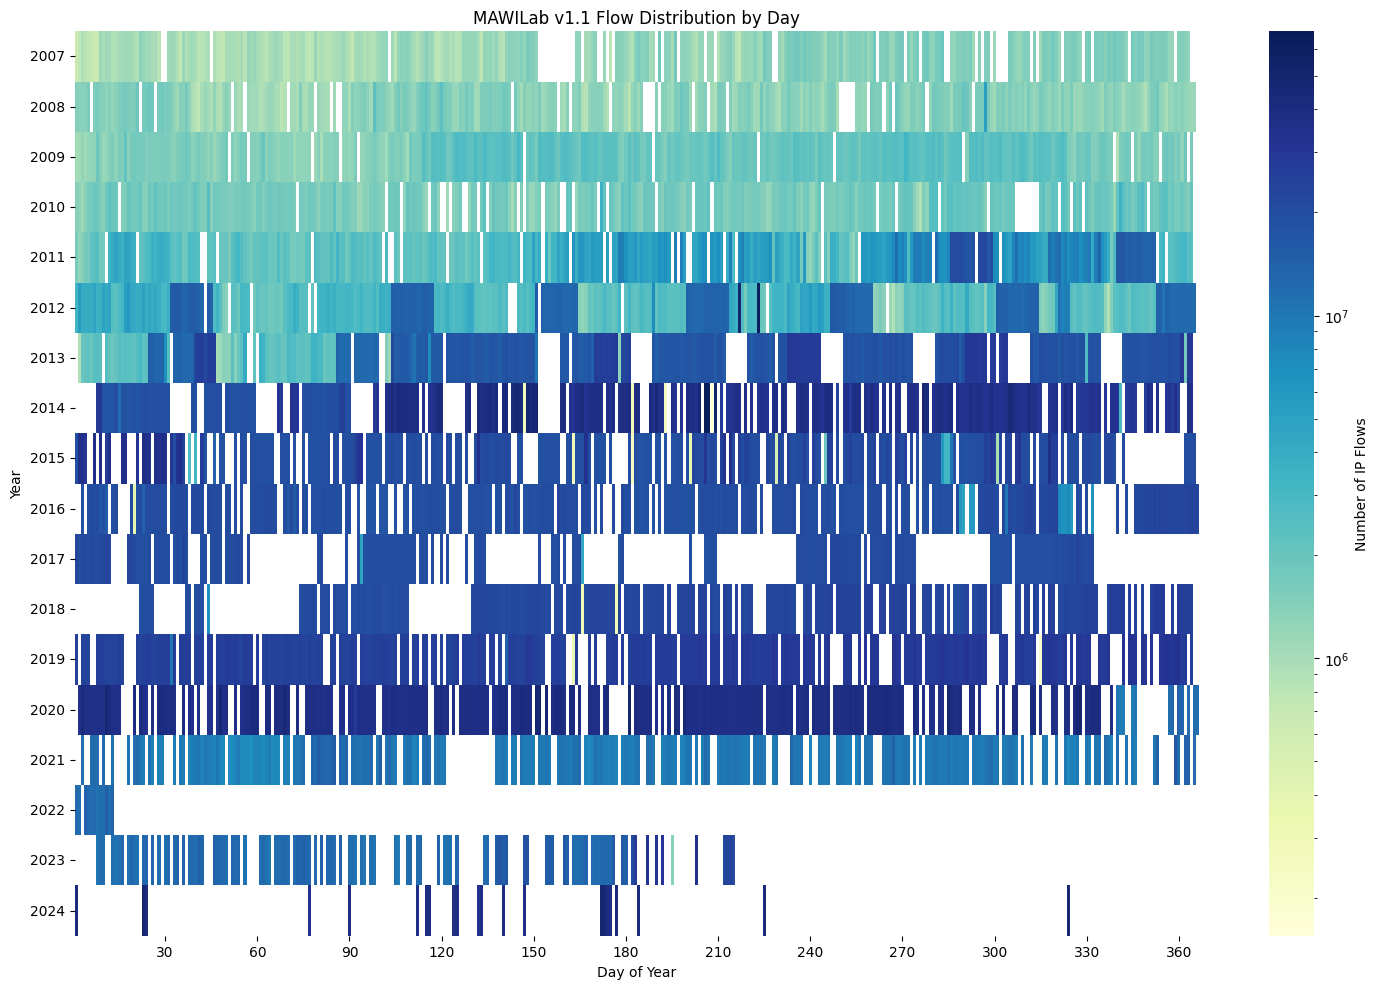

In [38]:
flows = label_distribution.to_pandas().set_index('date', drop=True).sum(axis=1)

# Build a DataFrame with year/day
df = flows.to_frame(name="num_flows").reset_index(names="date")
df["year"] = df["date"].dt.year
df["day_of_year"] = df["date"].dt.dayofyear

# Pivot into year × day grid
coverage_grid_flows = (
    df.pivot(index="year", columns="day_of_year", values="num_flows")
    .sort_index()
)

# Fill missing days with 0 or NaN depending on preference
coverage_grid_flows = coverage_grid_flows.fillna(0)

# Plot
fig_width, fig_height = 15, 10
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    coverage_grid_flows,
    cmap="YlGnBu",
    norm=LogNorm(),
    cbar_kws={
        'label': 'Number of IP Flows',
        'format': mtick.LogFormatterSciNotation(base=10)
    },
    ax=ax
)

# Customize tick labels
num_years = coverage_grid_flows.shape[0]
start_date, end_date = flows.index.min(), flows.index.max()

ax.set_yticks(np.arange(0.5, num_years))
ax.set_yticklabels(coverage_grid_flows.index, rotation=0)

ax.set_xticks(np.arange(29, 365, 30) + 0.5)
ax.set_xticklabels([f'{i+1}' for i in range(29, 365, 30)], rotation=0)

plt.title("MAWILab v1.1 Flow Distribution by Day")
plt.xlabel("Day of Year")
plt.ylabel("Year")

plt.tight_layout()
plt.show()


## Taxonomy distribution

In [14]:
taxonomies = taxonomy_distribution.columns
taxonomies.remove('date')

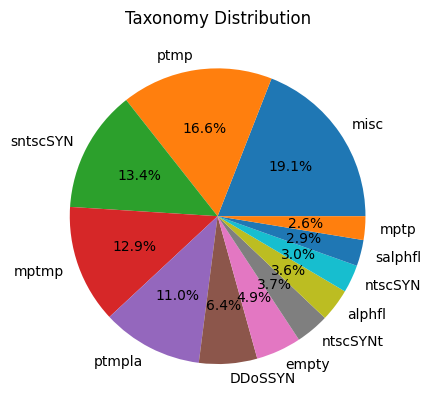

In [15]:
threshold_pct = 2.5

counts = taxonomy_distribution.select(taxonomies).sum().to_pandas().iloc[0]
total = counts.sum()
percent = counts / total * 100

mask = percent >= threshold_pct
filtered_counts = counts[mask].copy()
misc_sum = counts[~mask].sum()
if misc_sum > 0:
    filtered_counts.loc["misc"] = misc_sum

filtered_counts = filtered_counts.sort_values(ascending=False)

filtered_counts.plot.pie(
    autopct='%1.1f%%',
    ylabel="",
    title=f"Taxonomy Distribution"
)
plt.show()

In [53]:
taxonomy_distribution_1mo = (
    taxonomy_distribution
    .group_by(month=pl.col("date").dt.truncate("1mo"))
    .agg(pl.exclude("date").sum())
    .sort("month")
).to_pandas().set_index('month', drop=True)

taxonomy_distribution_1mo = taxonomy_distribution_1mo.reindex(sorted(taxonomy_distribution_1mo.columns), axis=1)

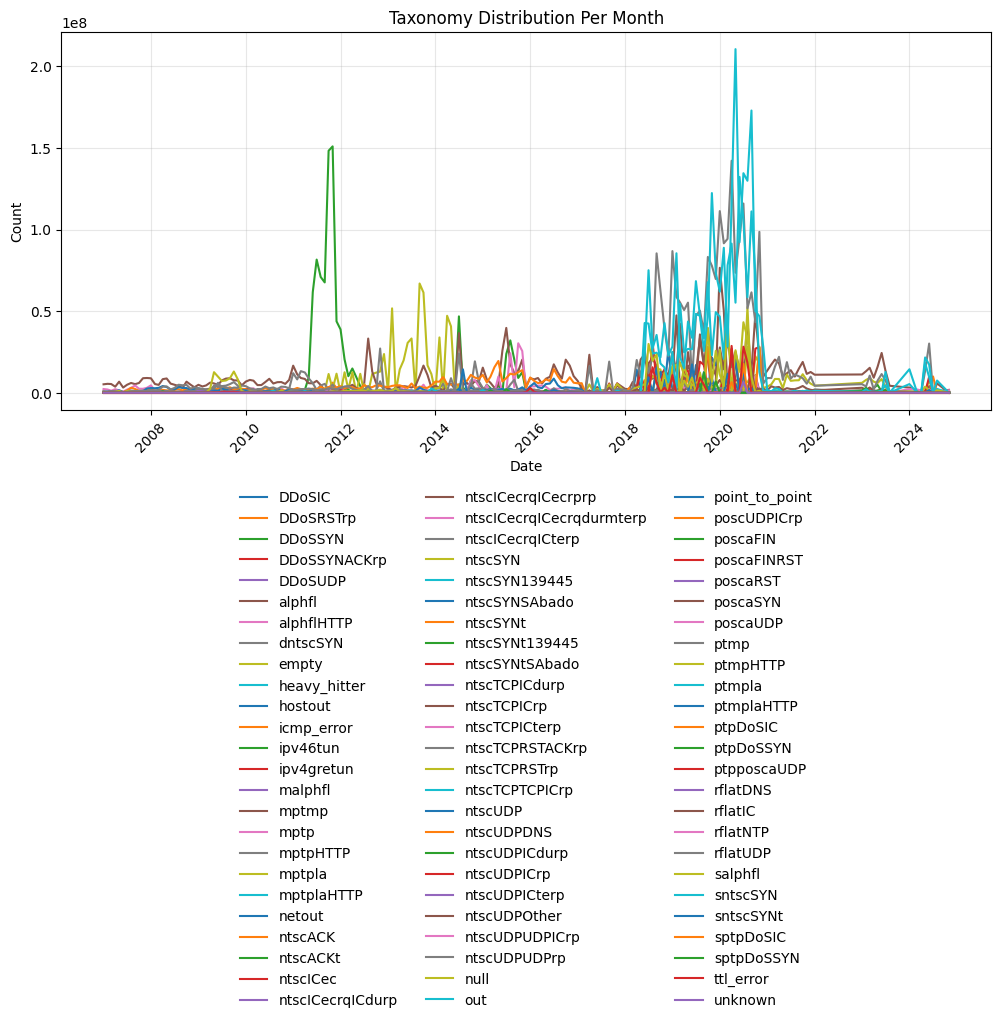

In [54]:
plt.figure(figsize=(12, 6))
for column in taxonomy_distribution_1mo.columns:
    sns.lineplot(
        x=taxonomy_distribution_1mo.index,
        y=taxonomy_distribution_1mo[column],
        label=column
    )

plt.title("Taxonomy Distribution Per Month")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

In [55]:
taxonomy_distribution_1mo_rel = taxonomy_distribution_1mo.div(
    taxonomy_distribution_1mo.sum(axis=1), axis=0) * 100

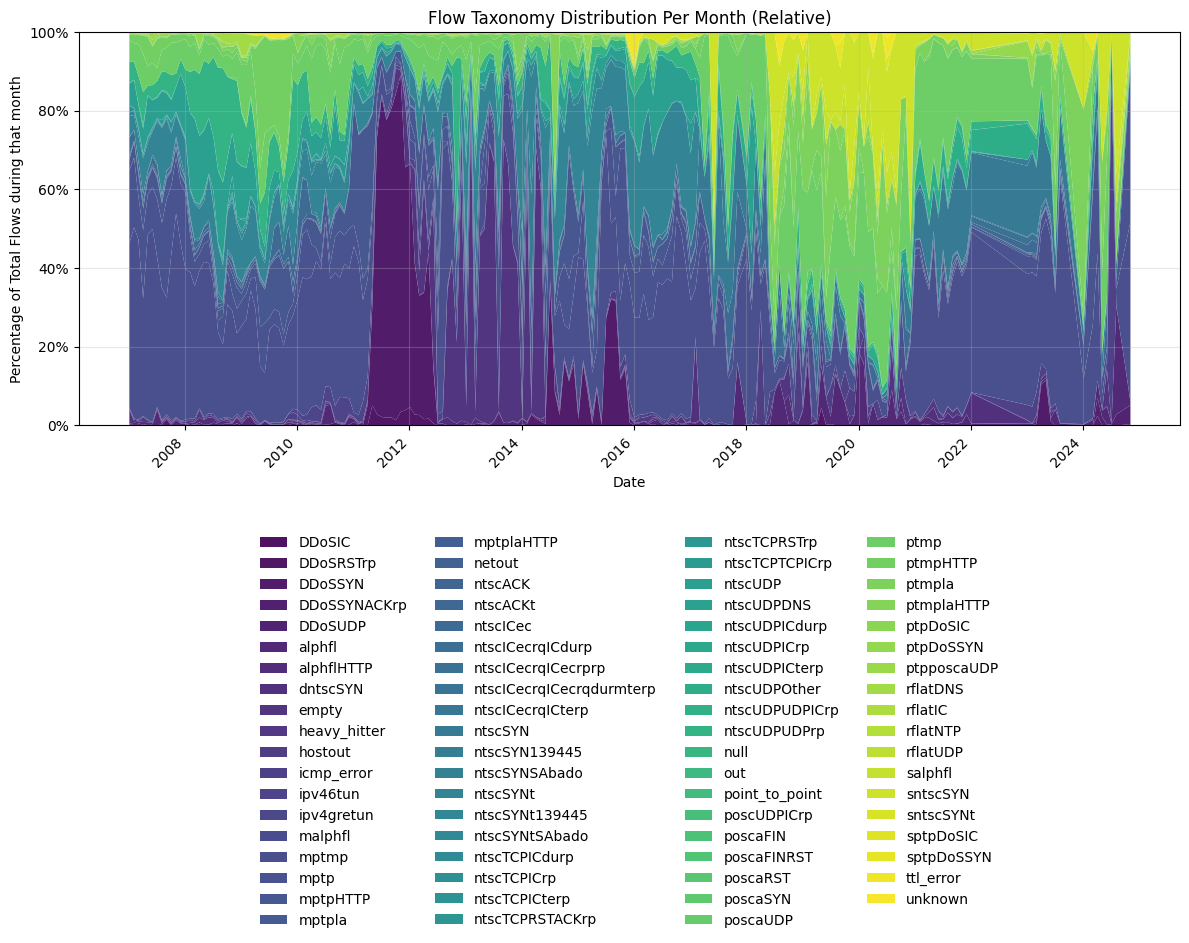

In [56]:
plt.figure(figsize=(12, 10))
tax_cols = list(taxonomy_distribution_1mo_rel.columns)
tax_palette = sns.color_palette("viridis", n_colors=len(tax_cols))
taxonomy_distribution_1mo_rel[tax_cols].fillna(0).plot.area(
    stacked=True,
    color=tax_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("Flow Taxonomy Distribution Per Month (Relative)")
plt.xlabel("Date")
plt.ylabel("Percentage of Total Flows during that month")
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

## Heuristic distribution

In [57]:
heuristics = heuristic_distribution.columns
heuristics.remove('date')

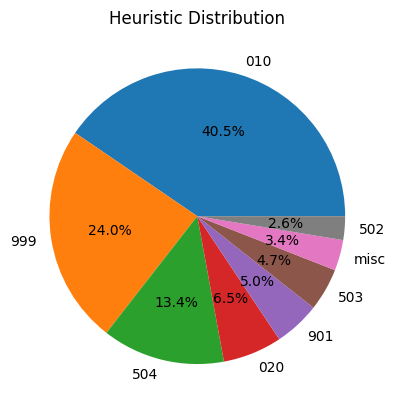

In [58]:
threshold_pct = 2.5

counts = heuristic_distribution.select(heuristics).sum().to_pandas().iloc[0]
total = counts.sum()
percent = counts / total * 100

mask = percent >= threshold_pct
filtered_counts = counts[mask].copy()
misc_sum = counts[~mask].sum()
if misc_sum > 0:
    filtered_counts.loc["misc"] = misc_sum

filtered_counts = filtered_counts.sort_values(ascending=False)

filtered_counts.plot.pie(
    autopct='%1.1f%%',
    ylabel="",
    title=f"Heuristic Distribution"
)
plt.show()

In [63]:
heuristic_distribution_1mo = (
    heuristic_distribution
    .group_by(month=pl.col("date").dt.truncate("1mo"))
    .agg(pl.exclude("date").sum())
    .sort("month")
).to_pandas().set_index('month', drop=True)

heuristic_distribution_1mo = heuristic_distribution_1mo.reindex(sorted(heuristic_distribution_1mo.columns), axis=1)

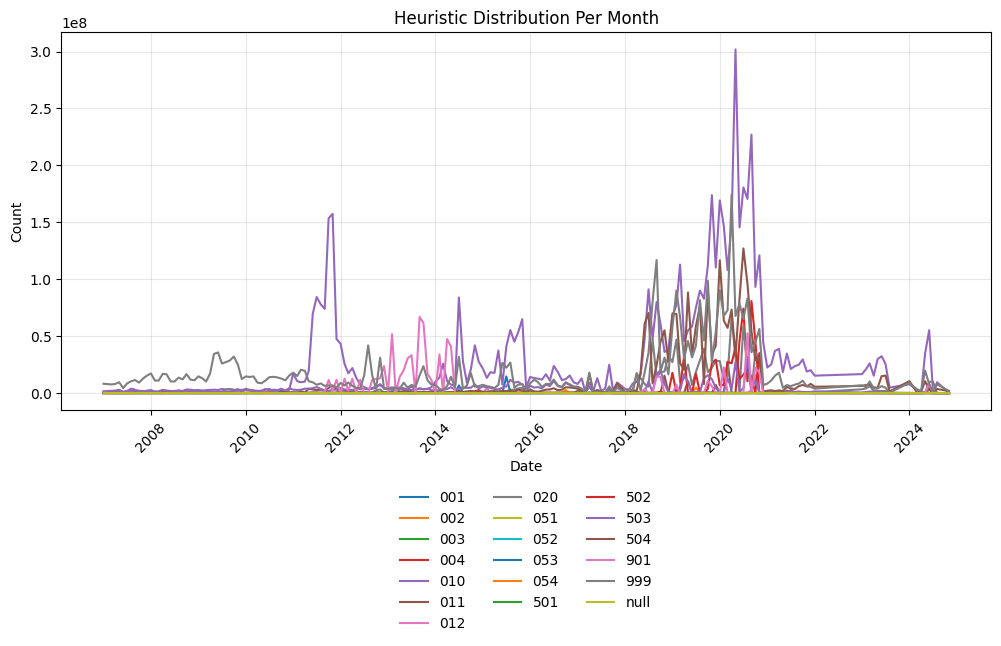

In [64]:
plt.figure(figsize=(12, 6))
for column in heuristic_distribution_1mo.columns:
    sns.lineplot(
        x=heuristic_distribution_1mo.index,
        y=heuristic_distribution_1mo[column],
        label=column
    )

plt.title("Heuristic Distribution Per Month")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

In [65]:
heuristic_distribution_1mo_rel = heuristic_distribution_1mo.div(
    heuristic_distribution_1mo.sum(axis=1), axis=0) * 100

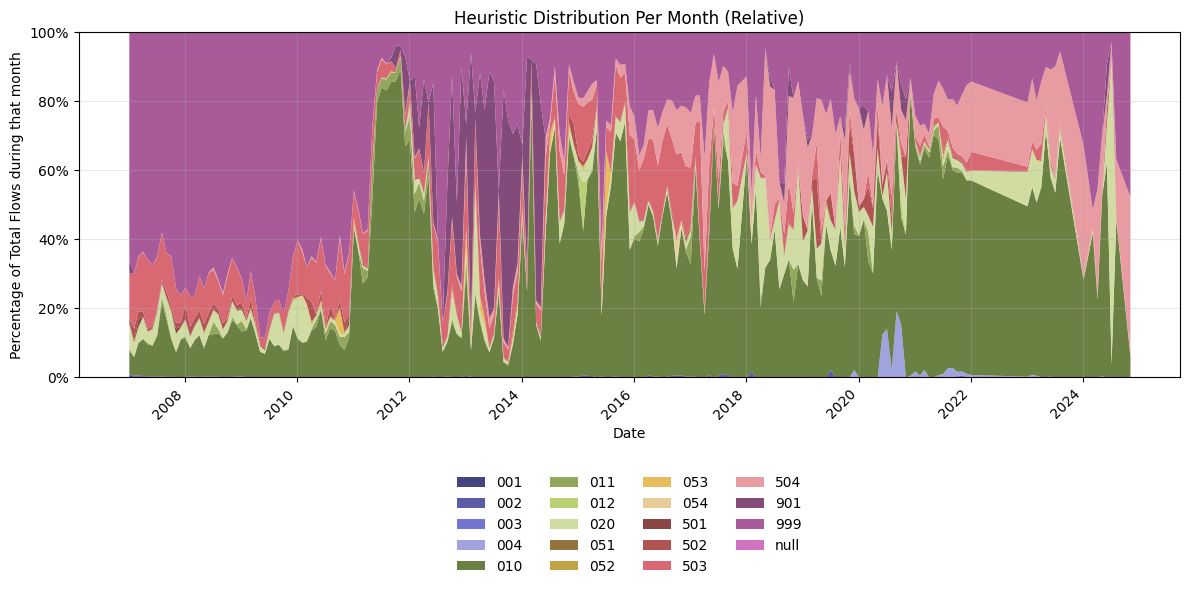

In [66]:
plt.figure(figsize=(12, 6))
heur_cols = list(heuristic_distribution_1mo_rel.columns)
heur_palette = sns.color_palette("tab20b", n_colors=len(heur_cols))
heuristic_distribution_1mo_rel[heur_cols].fillna(0).plot.area(
    stacked=True,
    color=heur_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("Heuristic Distribution Per Month (Relative)")
plt.xlabel("Date")
plt.ylabel("Percentage of Total Flows during that month")
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()